# This notebook is to test the exact bayesian optimization framework proposed

## 0 - Imports

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from numpy.linalg import inv, eigvalsh

## 1 - Define functions to estimate EI intervals

### 1.1 - Interval helpers

In [38]:
def split_intervals(intervals):
    """Split each [L,R] into [L,M] and [M,R]."""
    out = []
    for L, R in intervals:
        M = 0.5*(L+R)
        out.append((L, M))
        out.append((M, R))
    return out

def interval_midpoints(intervals):
    """Return midpoints as column vector suitable for sklearn (n,1)."""
    mids = [0.5*(L+R) for (L, R) in intervals]
    return np.array(mids, dtype=float).reshape(-1, 1)

### 1.2 - Bounds for RBF evaluation

In [ ]:
def _rbf_k_bounds_on_interval(L, R, x_i, sigma_f2, ell):
    """
    Bounds for k(x, x_i) = sigma_f^2 * exp( - (x-x_i)^2 / (2 ell^2) )
    for x in [L, R]. Returns (k_min, k_max).
    """
    # Distances x in [L,R] to x_i
    if L <= x_i <= R:
        dmin = 0.0
    else:
        dmin = min(abs(L - x_i), abs(R - x_i))
    dmax = max(abs(L - x_i), abs(R - x_i))
    k_max = sigma_f2 * np.exp(- (dmin**2) / (2*ell**2))
    k_min = sigma_f2 * np.exp(- (dmax**2) / (2*ell**2))
    return k_min, k_max

: 

### 1.3 - Bounds for mean calculation

In [ ]:
def _interval_linear_form_bounds(alpha, kmins, kmaxs):
    """
    Bounds for mu(x) = sum_i alpha_i * k_i(x) with k_i(x) in [kmin_i, kmax_i].
    """
    lo = 0.0
    hi = 0.0
    for a, kmn, kmx in zip(alpha, kmins, kmaxs):
        if a >= 0:
            lo += a * kmn
            hi += a * kmx
        else:
            lo += a * kmx
            hi += a * kmn
    return lo, hi

: 

### 1.4 - Bounds for q

In [ ]:
def _quadratic_form_bounds_over_box(A, kmins, kmaxs):
    """
    Conservative bounds for q(k)=k^T A k over the hyperrectangle k_i in [kmin_i, kmax_i].
    We use eigenvalue (Rayleigh) bounds with ||k||^2 bounds:
      λ_min(A)*||k||^2_min <= q(k) <= λ_max(A)*||k||^2_max
    """
    lam_min, lam_max = np.min(eigvalsh(A)), np.max(eigvalsh(A))
    # Norm bounds from component-wise intervals
    # Lower ||k||^2 can be 0 if any component interval contains 0; here k_i>0 (RBF) so:
    k2_min = np.sum(np.array(kmins)**2)
    k2_max = np.sum(np.array(kmaxs)**2)
    q_min = lam_min * k2_min
    q_max = lam_max * k2_max
    return q_min, q_max

: 

### 1.5 - Bounds for EI

In [ ]:
def _ei_minmax_given_mu_sigma(mu_lo, mu_hi, sig_lo, sig_hi, fmin):
    """
    Monotonicity for minimization-EI: EI decreases with mu, increases with sigma.
    So:
      EI_min at (mu_hi, sig_lo)
      EI_max at (mu_lo, sig_hi)
    """
    def EI(mu, sig):
        if sig <= 0:
            return np.array([0.0])
        z = (fmin - mu) / sig
        return (fmin - mu)*norm.cdf(z) + sig*norm.pdf(z)
    EI_min = EI(mu_hi, max(0.0, sig_lo))
    EI_max = EI(mu_lo, max(0.0, sig_hi))
    return EI_min.item(), EI_max.item()

: 

### 1.6 - Bounds general

In [ ]:
def ei_interval_on_subdomain(gp, L, R):
    """
    Compute a conservative interval [EI_min, EI_max] on x in [L, R] for a fitted
    sklearn GaussianProcessRegressor with kernel = Constant * RBF (SE) and scalar noise alpha.
    Assumes MINIMIZATION EI.
    """
    # --- Extract learned hyperparams ---
    # kernel_ is the fitted kernel. Expect Constant * RBF (possibly wrapped).
    k = gp.kernel_
    # Peel Constant * RBF
    if isinstance(k, ConstantKernel) and isinstance(k.k2, RBF):
        sigma_f2 = float(k.k1.constant_value)  # signal variance (amplitude)
        ell = float(k.k2.length_scale)
    elif hasattr(k, 'k1') and hasattr(k, 'k2') and isinstance(k.k1, ConstantKernel) and isinstance(k.k2, RBF):
        sigma_f2 = float(k.k1.constant_value)
        ell = float(k.k2.length_scale)
    else:
        raise ValueError("Kernel must be ConstantKernel * RBF for this interval bound.")

    Xtr = gp.X_train_.ravel()
    ytr = gp.y_train_.ravel()
    y_mean = getattr(gp, "_y_train_mean", 0.0)  # present when normalize_y=True

    # Noise variance (alpha) as used in the GP fit (scalar recommended)
    # If alpha is array-like, take mean as a fallback.
    alpha_noise = gp.alpha if np.isscalar(gp.alpha) else float(np.mean(gp.alpha))

    # --- Build K and its inverse ---
    # K = k(X,X) + alpha I with learned hyperparams (no WhiteKernel here)
    def rbf(xx, yy):
        xx = np.atleast_2d(xx).T
        yy = np.atleast_2d(yy).T
        d2 = (xx - yy.T)**2
        return sigma_f2 * np.exp(- d2 / (2*ell**2))

    K = rbf(Xtr, Xtr) + alpha_noise * np.eye(len(Xtr))
    A = inv(K)  # K^{-1}

    # alpha_vec = K^{-1} (y - y_mean)
    alpha_vec = A @ (ytr - y_mean)

    # Current best (minimization) on original scale (sklearn returns predictions on original scale)
    fmin = np.min(ytr)

    # --- Bounds for k(x) components over x in [L, R] ---
    kmins = []
    kmaxs = []
    for xi in Xtr:
        kmn, kmx = _rbf_k_bounds_on_interval(L, R, xi, sigma_f2, ell)
        kmins.append(kmn)
        kmaxs.append(kmx)

    # --- Bounds for mu(x) = k(x)^T alpha + y_mean ---
    mu_lo_c, mu_hi_c = _interval_linear_form_bounds(alpha_vec, kmins, kmaxs)
    mu_lo, mu_hi = mu_lo_c + y_mean, mu_hi_c + y_mean

    # --- Bounds for sigma^2(x) = kxx - k(x)^T A k(x); here kxx = sigma_f2 ---
    # Bound q(x)=k^T A k over the box k_i in [kmin_i, kmax_i]
    q_lo, q_hi = _quadratic_form_bounds_over_box(A, kmins, kmaxs)
    sig2_lo = max(0.0, sigma_f2 - q_hi)  # worst case (largest subtraction) gives smallest variance
    sig2_hi = max(0.0, sigma_f2 - q_lo)  # best case (smallest subtraction) gives largest variance
    sig_lo, sig_hi = np.sqrt(sig2_lo), np.sqrt(sig2_hi)

    # --- EI interval via monotonicity ---
    EI_min, EI_max = _ei_minmax_given_mu_sigma(mu_lo, mu_hi, sig_lo, sig_hi, fmin)
    return (EI_min, EI_max)

: 

## 2 - Toy function to minimize

In [39]:
def f(x):
    return (x - 2)**2 + np.sin(5*x)

## 3 - EI Function

In [40]:
def expected_improvement(X, gp, y_min):
    mu, sigma = gp.predict(X, return_std=True)
    sigma = sigma.reshape(-1,1)
    mu = mu.reshape(-1,1)
    with np.errstate(divide='warn'):
        Z = (y_min - mu) / sigma # to minimize
        ei = (y_min - mu) * norm.cdf(Z) + sigma * norm.pdf(Z) # to minimize
        ei[sigma==0.0] = 0.0
    return ei.ravel()

## 4 - Define domain

In [41]:
a, b = 0.0, 4.0
intervals0 = [(a,b)]

## 5 - Iteration 0

### 5.1 - Sample at center

In [42]:
#x_c = 0.5*(a+b)
X = interval_midpoints(intervals0)
y = f(X)

### 5.2 - Build GP

In [43]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
gp.fit(X, y)

c:\Users\juan.florez\tamubo\venvs\venv313\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__constant_value is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 5.3 - Plot

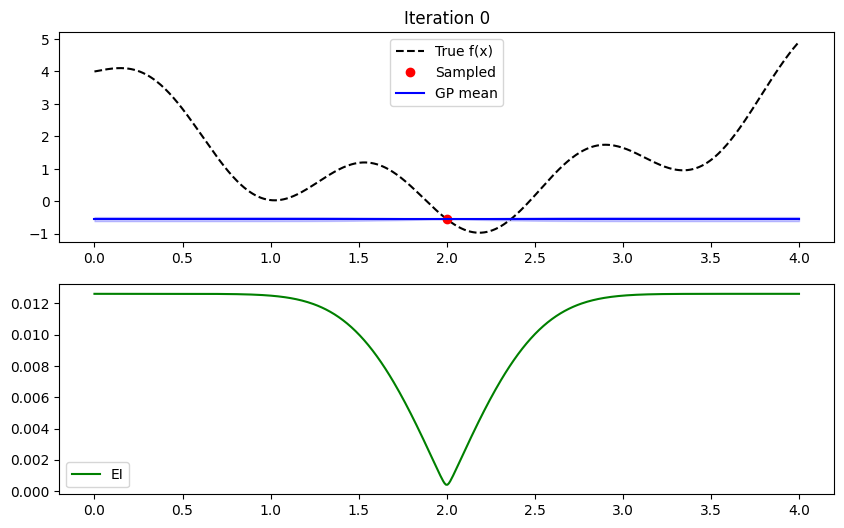

In [44]:
xx = np.linspace(a, b, 500).reshape(-1,1)
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 0")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.legend()
plt.show()

### 5.4 - Show EI interval estimation in 2 subdomains

In [47]:
intervals1 = split_intervals(intervals0)
for L,R in intervals1:
    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")

Interval [0.00, 2.00]: EI in [0.000728, 0.543839]
Interval [2.00, 4.00]: EI in [0.000728, 0.543839]


## 6 - Iteration 1

### 6.1 - Sample function at the midpoint of the feasible subdomains

In [49]:
X_new = interval_midpoints(intervals1)
y_new = f(X_new)

X = np.vstack([X, X_new])
y = np.vstack([y, y_new])

### 6.2 - Build GP

In [50]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 6.3 - Plot

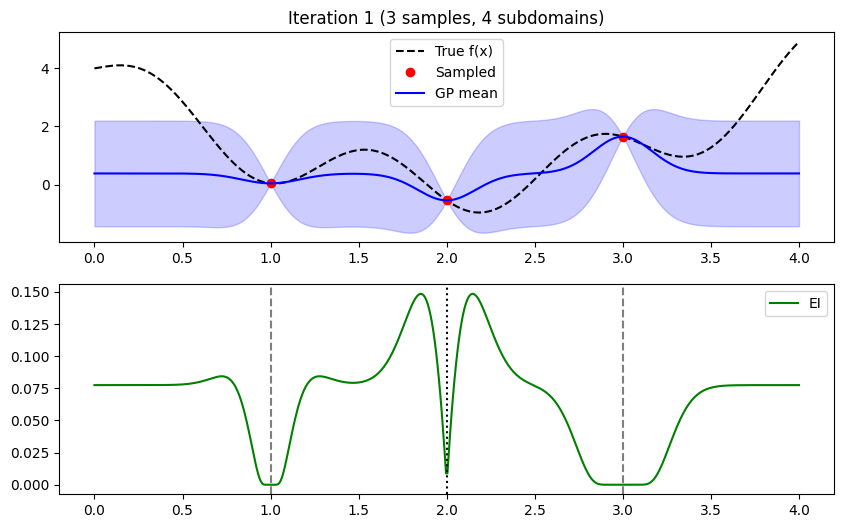

In [51]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 1 (3 samples, 4 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 6.4 - Show EI interval estimation in 4 subdomains

In [53]:
intervals2 = split_intervals(intervals1)
for L,R in intervals2:
    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")

Interval [0.00, 1.00]: EI in [0.000000, 0.160426]
Interval [1.00, 2.00]: EI in [0.000000, 0.881473]
Interval [2.00, 3.00]: EI in [0.000000, 0.398945]
Interval [3.00, 4.00]: EI in [0.000000, 0.038228]


## 7 - Iteration 2

### 7.1 - Sample point at the midpoint of the feasible subdomains

In [54]:
X_new = interval_midpoints(intervals2)
y_new = f(X_new)

X = np.vstack([X, X_new])
y = np.vstack([y, y_new])

### 7.2 - Build GP

In [55]:
gp.fit(X, y)

,kernel,1**2 * RBF(length_scale=0.5)
,alpha,1e-06
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,0
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,RBF(length_scale=0.5)
,kernel__k1__constant_value,1.0


### 7.3 - Plot

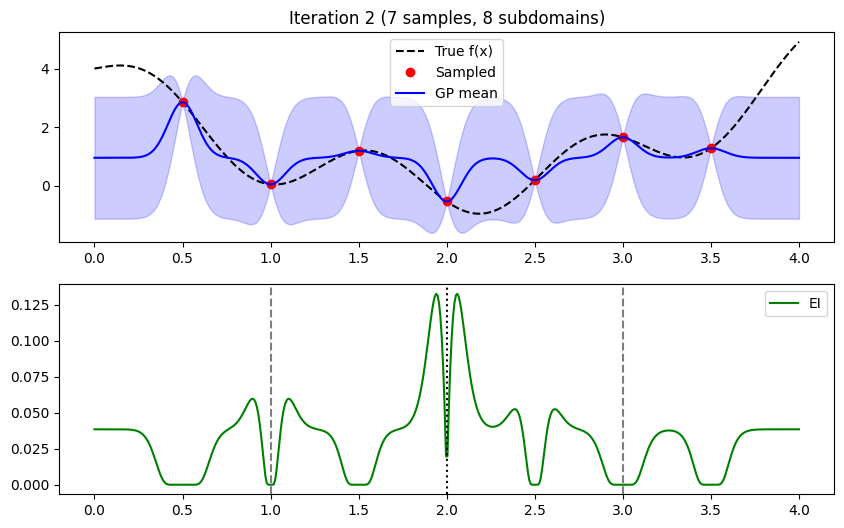

In [56]:
mu, sigma = gp.predict(xx, return_std=True)
ei = expected_improvement(xx, gp, np.min(y))

plt.figure(figsize=(10,6))
plt.subplot(2,1,1)
plt.plot(xx, f(xx), 'k--', label="True f(x)")
plt.plot(X, y, 'ro', label="Sampled")
plt.plot(xx, mu, 'b', label="GP mean")
plt.fill_between(xx.ravel(), mu-1.96*sigma, mu+1.96*sigma, alpha=0.2, color='b')
plt.legend(); plt.title("Iteration 2 (7 samples, 8 subdomains)")

plt.subplot(2,1,2)
plt.plot(xx, ei, 'g', label="EI")
plt.axvline((a+x_c)/2, color='k', ls='--', alpha=0.5) # subdomain split markers
plt.axvline((x_c+b)/2, color='k', ls='--', alpha=0.5)
plt.axvline(x_c, color='k', ls=':')
plt.legend()
plt.show()

### 7.4 - Show EI interval estimation in 8 subdomains

In [57]:
intervals3 = split_intervals(intervals2)
for L,R in intervals3:
    ei_min, ei_max = ei_interval_on_subdomain(gp, L, R)
    print(f"Interval [{L:.2f}, {R:.2f}]: EI in [{ei_min:.6f}, {ei_max:.6f}]")

Interval [0.00, 0.50]: EI in [0.000000, 0.003123]
Interval [0.50, 1.00]: EI in [0.000000, 0.182602]
Interval [1.00, 1.50]: EI in [0.000000, 0.491420]
Interval [1.50, 2.00]: EI in [0.000000, 0.860958]
Interval [2.00, 2.50]: EI in [0.000000, 1.688717]
Interval [2.50, 3.00]: EI in [0.000000, 0.231721]
Interval [3.00, 3.50]: EI in [0.000000, 0.034861]
Interval [3.50, 4.00]: EI in [0.000000, 0.017782]
